In [1]:
import pandas as pd
import numpy as np
import nltk
import re
import cv2
import os
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aiman\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\aiman\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aiman\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [3]:
captions_path = "../data/captions.txt"
df = pd.read_csv(captions_path, sep='|')
df.columns = df.columns.str.strip()

print("Dataset loaded:")
print(f"Total captions: {df.shape[0]}")
df.head()

Dataset loaded:
Total captions: 40455


,image_name,caption_number,caption_text
0,1000268201_693b08cb0e.jpg,0,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,1,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,2,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,3,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,4,A little girl in a pink dress going into a woo...


In [4]:
def preprocess_caption(caption):
    # Lowercase karo
    caption = str(caption).lower()
    # Sirf letters aur spaces rakho (punctuation hatao)
    caption = re.sub(r"[^a-z\s]", "", caption)
    # Tokenize karo (words mein tor do)
    tokens = word_tokenize(caption)
    return tokens

# Ek example pe test karo
sample_caption = df['caption_text'].iloc[0]
print("Original:", sample_caption)
print("Processed tokens:", preprocess_caption(sample_caption))

Original: A child in a pink dress is climbing up a set of stairs in an entry way .
Processed tokens: ['a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', 'entry', 'way']


In [5]:
stop_words = set(stopwords.words('english'))

def preprocess_caption_full(caption, remove_stopwords=False):
    caption = str(caption).lower()
    caption = re.sub(r"[^a-z\s]", "", caption)
    tokens = word_tokenize(caption)
    if remove_stopwords:
        tokens = [word for word in tokens if word not in stop_words]
    return tokens

# Test karo dono versions
sample_caption = df['caption_text'].iloc[0]
print("Original:", sample_caption)
print("\nWith stopwords:", preprocess_caption_full(sample_caption, remove_stopwords=False))
print("\nWithout stopwords:", preprocess_caption_full(sample_caption, remove_stopwords=True))

Original: A child in a pink dress is climbing up a set of stairs in an entry way .

With stopwords: ['a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', 'entry', 'way']

Without stopwords: ['child', 'pink', 'dress', 'climbing', 'set', 'stairs', 'entry', 'way']


In [6]:
# Poore dataset pe preprocessing apply karo (stopwords ke bina - clean version)
df['tokens'] = df['caption_text'].apply(lambda x: preprocess_caption_full(x, remove_stopwords=True))

# Cleaned caption (tokens wapis join kar ke ek string bana do, readable format ke liye)
df['cleaned_caption'] = df['tokens'].apply(lambda x: ' '.join(x))

print("Preprocessing complete!")
print(f"\nTotal rows processed: {df.shape[0]}")
print("\nSample before/after:")
df[['caption_text', 'cleaned_caption']].head()

Preprocessing complete!

Total rows processed: 40455

Sample before/after:


,caption_text,cleaned_caption
0,A child in a pink dress is climbing up a set o...,child pink dress climbing set stairs entry way
1,A girl going into a wooden building .,girl going wooden building
2,A little girl climbing into a wooden playhouse .,little girl climbing wooden playhouse
3,A little girl climbing the stairs to her playh...,little girl climbing stairs playhouse
4,A little girl in a pink dress going into a woo...,little girl pink dress going wooden cabin


In [7]:
# Saare cleaned tokens ko ek list mein jama karo
all_clean_words = []
for tokens in df['tokens']:
    all_clean_words.extend(tokens)

# Vocabulary (unique words)
vocab = sorted(set(all_clean_words))

print(f"Total words (with repetition): {len(all_clean_words)}")
print(f"Vocabulary size (unique words): {len(vocab)}")

# Word frequency count
from collections import Counter
word_freq = Counter(all_clean_words)

print("\nTop 10 most common words (after cleaning):")
for word, freq in word_freq.most_common(10):
    print(f"{word}: {freq}")

Total words (with repetition): 251045
Vocabulary size (unique words): 8661

Top 10 most common words (after cleaning):
dog: 8136
man: 7265
two: 5638
white: 3940
black: 3832
boy: 3581
woman: 3402
girl: 3328
wearing: 3062
people: 2883


In [8]:
import cv2

# Ek sample image load karo
sample_img_name = df['image_name'].iloc[0]
img_path = f"../data/images/{sample_img_name}"

img = cv2.imread(img_path)

print(f"Image name: {sample_img_name}")
print(f"Image shape (height, width, channels): {img.shape}")
print(f"Image dtype: {img.dtype}")

Image name: 1000268201_693b08cb0e.jpg
Image shape (height, width, channels): (500, 375, 3)
Image dtype: uint8


In [9]:
import random

# Time bachane ke liye, 500 random images ka sample check karo (saari 8091 check karne mein time lagega)
sample_images = random.sample(list(df['image_name'].unique()), 500)

channel_counts = Counter()
sizes = []

for img_name in sample_images:
    img_path = f"../data/images/{img_name}"
    img = cv2.imread(img_path)
    if img is not None:
        channel_counts[img.shape[2]] += 1
        sizes.append((img.shape[0], img.shape[1]))

print("Channel distribution (out of 500 sample images):")
print(channel_counts)

print(f"\nUnique image sizes found: {len(set(sizes))}")
print("Sample sizes:", list(set(sizes))[:5])

Channel distribution (out of 500 sample images):
Counter({3: 500})

Unique image sizes found: 148
Sample sizes: [(354, 500), (500, 261), (500, 380), (500, 334), (312, 500)]


In [10]:
def preprocess_image(img_path, target_size=(224, 224)):
    img = cv2.imread(img_path)
    # BGR se RGB mein convert karo (OpenCV BGR mein load karta hai by default)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Resize karo fixed size mein
    img = cv2.resize(img, target_size)
    # Normalize karo (0-255 ko 0-1 range mein le aao)
    img = img.astype(np.float32) / 255.0
    return img

# Test karo ek image pe
sample_img_name = df['image_name'].iloc[0]
img_path = f"../data/images/{sample_img_name}"
processed_img = preprocess_image(img_path)

print(f"Processed image shape: {processed_img.shape}")
print(f"Data type: {processed_img.dtype}")
print(f"Min pixel value: {processed_img.min()}")
print(f"Max pixel value: {processed_img.max()}")

# Visualize karo
plt.imshow(processed_img)
plt.title(f"Resized & Normalized: {sample_img_name}")
plt.axis('off')
plt.show()

Processed image shape: (224, 224, 3)
Data type: float32
Min pixel value: 0.0
Max pixel value: 1.0


NameError: name 'plt' is not defined

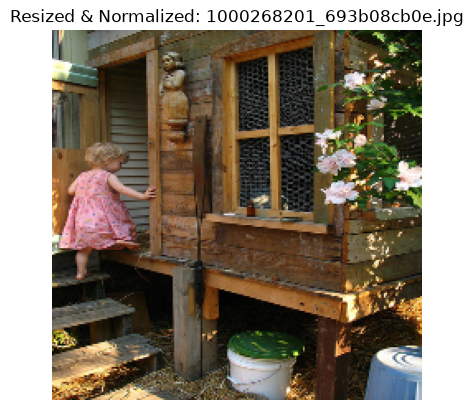

In [11]:
import matplotlib.pyplot as plt

plt.imshow(processed_img)
plt.title(f"Resized & Normalized: {sample_img_name}")
plt.axis('off')
plt.show()

In [12]:
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../data/processed/images", exist_ok=True)
print("Folders created!")

Folders created!


In [13]:
# Sirf zaroori columns save karo
cleaned_df = df[['image_name', 'caption_number', 'caption_text', 'cleaned_caption']]
cleaned_df.to_csv("../data/processed/cleaned_captions.csv", index=False)

print("Cleaned captions saved!")
print(f"Saved {cleaned_df.shape[0]} rows to data/processed/cleaned_captions.csv")

Cleaned captions saved!
Saved 40455 rows to data/processed/cleaned_captions.csv


In [14]:
from tqdm import tqdm

target_size = (224, 224)
processed_count = 0
failed_images = []

unique_images = df['image_name'].unique()

for img_name in tqdm(unique_images):
    try:
        img_path = f"../data/images/{img_name}"
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, target_size)
        
        # Save karo processed folder mein (0-255 range mein hi save karo, image format ke liye)
        save_path = f"../data/processed/images/{img_name}"
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)  # save ke liye wapis BGR
        cv2.imwrite(save_path, img_bgr)
        processed_count += 1
    except Exception as e:
        failed_images.append(img_name)

print(f"\nProcessed and saved: {processed_count} images")
print(f"Failed: {len(failed_images)} images")

100%|██████████| 8091/8091 [01:27<00:00, 92.10it/s] 


Processed and saved: 8091 images
Failed: 0 images
